# Predicting Stellar Class
**Kaggle Playground Series S6E6**: classify each object as a `GALAXY`, `QSO` (quasar) or `STAR`.

- **Metric:** balanced accuracy, the mean of the three per-class recalls. Every class counts equally even though
  65% of the rows are galaxies, so the decision rule matters as much as the model.
- **Data:** 577k training and 247k test objects, generated synthetically from the
  [SDSS17 stellar classification dataset](https://www.kaggle.com/datasets/fedesoriano/stellar-classification-dataset-sdss17)
  (100k real spectra, called the *original* dataset below). Features: sky position (`alpha`, `delta`), the five
  photometric magnitudes `u g r i z`, `redshift`, and two categorical columns.
- **Approach**, taken from the winning write-ups and the strongest public notebooks:
  1. astronomy features: colour indices (magnitude differences), fluxes, redshift interactions, sky geometry;
  2. binned "keys" (colour x redshift cells, sky cells, quantile bins) described three ways: frequency, class rates
     in the original data (no competition labels involved), and fold-safe target encoding;
  3. LightGBM and XGBoost trained with balanced class weights on the same 5 folds;
  4. probability blend, then per-class multipliers tuned on out-of-fold predictions to maximise balanced accuracy.

The competition closed on 30 June 2026. The submission at the end is a late submission, which Kaggle still
scores on both the public and private leaderboards.

In [1]:
import io, subprocess, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import TargetEncoder
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)

COMP = 'playground-series-s6e6'
SEED = 42
N_FOLDS = 5
TARGET = 'class'
CLASSES = np.array(['GALAXY', 'QSO', 'STAR'])

# Plot styling: one fixed colour per class, recessive grid
BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
CLASS_COLOR = dict(zip(CLASSES, [BLUE, ORANGE, AQUA]))
plt.rcParams.update({
    'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e6e5e1', 'grid.linewidth': 0.6, 'axes.axisbelow': True,
    'axes.edgecolor': '#9a9994', 'axes.titleweight': 'bold', 'axes.titlesize': 11, 'font.size': 9,
    'lines.linewidth': 2,
})

## 1. Load data

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample = pd.read_csv('sample_submission.csv')

# Original SDSS17 dataset. Download with:
#   kaggle datasets download fedesoriano/stellar-classification-dataset-sdss17 -p original --unzip
orig = pd.read_csv('original/star_classification.csv')
print('train', train.shape, '| test', test.shape, '| original', orig.shape)
train.head()

train (577347, 12) | test (247435, 11) | original (100000, 18)


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


## 2. EDA
### 2.1 Structure, class balance and the two categorical columns

In [3]:
BANDS = ['u', 'g', 'r', 'i', 'z']
RAW = ['alpha', 'delta'] + BANDS + ['redshift']

summary = pd.DataFrame({
    'dtype': train.drop(columns=['id']).dtypes.astype(str),
    'n_unique': train.drop(columns=['id']).nunique(),
    'missing': train.drop(columns=['id']).isna().sum(),
})
display(summary)
balance = pd.DataFrame({'train': train[TARGET].value_counts(normalize=True),
                        'original': orig[TARGET].value_counts(normalize=True)}).loc[CLASSES]
display(balance.round(4))
print('Always predicting GALAXY: accuracy', round(balance.loc['GALAXY', 'train'], 3), 'but balanced accuracy 0.333')

# The two categorical columns are thresholds on colour indices (found by the community; checked here)
def spectral_type(g, r):
    return pd.cut(r - g, [-np.inf, -1, -0.5, 0, np.inf], labels=['M', 'G/K', 'A/F', 'O/B']).astype(str)

def galaxy_population(u, r):
    return pd.cut(u - r, [-np.inf, 2.2, np.inf], labels=['Blue_Cloud', 'Red_Sequence']).astype(str)

both = pd.concat([train, test])
print('spectral_type == cut(r - g):     ', spectral_type(both['g'], both['r']).eq(both['spectral_type']).mean())
print('galaxy_population == cut(u - r): ', galaxy_population(both['u'], both['r']).eq(both['galaxy_population']).mean())

,dtype,n_unique,missing
alpha,float64,439819,0
delta,float64,444062,0
u,float64,577347,0
g,float64,577347,0
r,float64,577347,0
i,float64,577347,0
z,float64,577347,0
redshift,float64,573975,0
spectral_type,str,4,0
galaxy_population,str,2,0


,train,original
class,,
GALAXY,0.6538,0.5944
QSO,0.2029,0.1896
STAR,0.1433,0.2159


Always predicting GALAXY: accuracy 0.654 but balanced accuracy 0.333
spectral_type == cut(r - g):      1.0


galaxy_population == cut(u - r):  1.0


### 2.2 Redshift separates the classes, but not cleanly
Stars sit at redshift ~0, galaxies at 0-1 and quasars mostly above 1. The synthetic generator blurred redshift,
so the classes overlap near 0 (galaxy vs star) and near 1 (galaxy vs quasar). The colours have to resolve those rows.

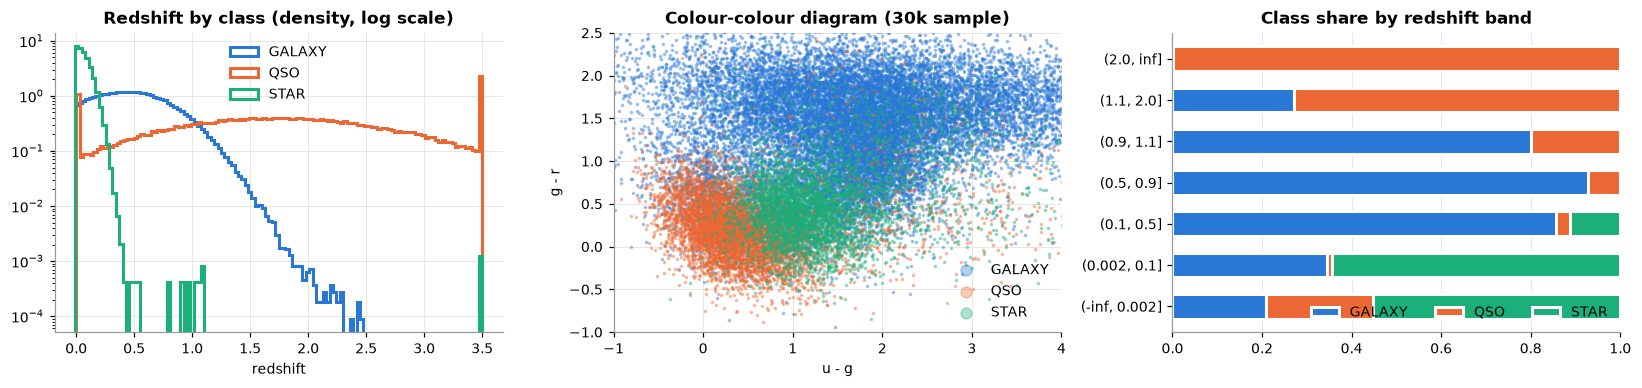

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for cls in CLASSES:
    zs = train.loc[train[TARGET] == cls, 'redshift']
    axes[0].hist(zs.clip(-0.1, 3.5), bins=120, histtype='step', linewidth=2, color=CLASS_COLOR[cls], label=cls, density=True)
axes[0].set_yscale('log'); axes[0].set_title('Redshift by class (density, log scale)'); axes[0].set_xlabel('redshift')
axes[0].legend(frameon=False)

smp = train.sample(min(30_000, len(train)), random_state=SEED)
for cls in CLASSES:
    s = smp[smp[TARGET] == cls]
    axes[1].scatter(s['u'] - s['g'], s['g'] - s['r'], s=2, alpha=0.35, color=CLASS_COLOR[cls], label=cls, rasterized=True)
axes[1].set_xlim(-1, 4); axes[1].set_ylim(-1, 2.5)
axes[1].set_title('Colour-colour diagram (30k sample)'); axes[1].set_xlabel('u - g'); axes[1].set_ylabel('g - r')
axes[1].legend(frameon=False, markerscale=5)

zbin = pd.cut(train['redshift'], [-np.inf, 0.002, 0.1, 0.5, 0.9, 1.1, 2, np.inf])
share = pd.crosstab(zbin, train[TARGET], normalize='index')[CLASSES]
left = np.zeros(len(share))
for cls in CLASSES:
    axes[2].barh(share.index.astype(str), share[cls], left=left, color=CLASS_COLOR[cls], label=cls,
                 height=0.6, edgecolor='white', linewidth=2)
    left += share[cls].values
axes[2].set_title('Class share by redshift band'); axes[2].set_xlim(0, 1); axes[2].legend(frameon=False, ncol=3, loc='lower right')
plt.tight_layout(); plt.show()

### 2.3 Train vs test, and synthetic vs original (adversarial validation)

In [5]:
ADV_PARAMS = dict(objective='binary', learning_rate=0.1, num_leaves=63, verbose=-1, n_jobs=-1, seed=SEED)

def adversarial_auc(a, b, cols, n=100_000):
    from sklearn.metrics import roc_auc_score
    a = a.sample(min(n, len(a)), random_state=SEED)
    b = b.sample(min(n, len(b)), random_state=SEED)
    Xab = pd.concat([a[cols], b[cols]], ignore_index=True)
    t = np.r_[np.zeros(len(a)), np.ones(len(b))]
    Xa, Xb, ta, tb = train_test_split(Xab, t, test_size=0.3, random_state=SEED, stratify=t)
    m = lgb.train(ADV_PARAMS, lgb.Dataset(Xa, ta), 200)
    return roc_auc_score(tb, m.predict(Xb))

print(f'Adversarial AUC train vs test:     {adversarial_auc(train, test, RAW):.4f}   (~0.5 => same distribution)')
print(f'Adversarial AUC train vs original: {adversarial_auc(train, orig, RAW):.4f}')

Adversarial AUC train vs test:     0.4999   (~0.5 => same distribution)


Adversarial AUC train vs original: 0.9304


**EDA takeaways**
- No missing values. `spectral_type` and `galaxy_population` are exact thresholds on `g - r` and `u - r`, so they
  add nothing a tree cannot find, but they let us rebuild the same columns for the original data.
- Redshift is the dominant signal; the hard rows are low-redshift galaxy vs star and redshift ~1 galaxy vs quasar.
- Train and test match. The original data is clearly distinguishable from the synthetic rows, so it is used through
  per-cell class rates (priors) rather than appended as training rows.

## 3. Feature engineering
Adapted from the strongest public XGBoost notebook (Chris Deotte, "XGB v5"), trimmed to what trains in reasonable time
on a laptop CPU:
- **Colour indices:** all 10 pairwise magnitude differences (`u - g`, `g - r`, ...), the astronomer's way to read an
  object's spectrum shape from five filters.
- **Brightness profile:** magnitude mean/std/min/max/range, slope and curvature across the bands, linear fluxes.
- **Redshift interactions:** redshift x each magnitude and colour, magnitude / |redshift|, a distance-modulus proxy
  `5 log10 |z|` and "absolute magnitude" proxies.
- **Sky geometry:** sin/cos of the coordinates and the 3-D unit vector.
- **Keys:** binned cells (colour x redshift, sky patches, quantile bins and their pairs). Each key gets a frequency,
  its class rates in the original SDSS data, and a fold-safe target encoding (added inside the CV loop).

In [6]:
COLOR_PAIRS = [('u', 'g'), ('g', 'r'), ('r', 'i'), ('i', 'z'), ('u', 'r'), ('u', 'i'), ('u', 'z'), ('g', 'i'), ('g', 'z'), ('r', 'z')]
EPS = 1e-6

def make_features(df):
    out = df[RAW].astype('float64').copy()
    out['spectral_type'] = spectral_type(df['g'], df['r'])
    out['galaxy_population'] = galaxy_population(df['u'], df['r'])
    for a, b in COLOR_PAIRS:
        out[f'{a}_{b}'] = df[a] - df[b]
    mags = df[BANDS].to_numpy(dtype='float64')
    out['mag_mean'], out['mag_std'] = mags.mean(1), mags.std(1, ddof=1)
    out['mag_min'], out['mag_max'] = mags.min(1), mags.max(1)
    out['mag_range'] = out['mag_max'] - out['mag_min']
    x = np.arange(5) - 2.0
    out['mag_slope'] = (mags - mags.mean(1, keepdims=True)) @ x / (x ** 2).sum()
    out['mag_curvature'] = df['u'] - 2 * df['r'] + df['z']
    out['blue_curvature'] = df['u'] - 2 * df['g'] + df['r']
    out['red_curvature'] = df['r'] - 2 * df['i'] + df['z']
    flux = 10 ** (-0.4 * np.clip(mags, -30, 30))
    for j, b in enumerate(BANDS):
        out[f'flux_{b}'] = flux[:, j]
    out['flux_std'], out['flux_range'] = flux.std(1, ddof=1), flux.max(1) - flux.min(1)

    z = df['redshift']
    az = z.abs()
    out['redshift_abs'], out['redshift_log1p'] = az, np.log1p(az)
    out['redshift_is_neg'] = (z < 0).astype('int8')
    distmod = 5 * np.log10(az + EPS)
    out['distmod_proxy'] = distmod
    for b in BANDS:
        out[f'{b}_x_redshift'] = df[b] * z
        out[f'{b}_over_redshift'] = df[b] / (az + EPS)
        out[f'{b}_absmag'] = df[b] - distmod
    for c in ['u_g', 'g_r', 'r_i', 'i_z']:
        out[f'{c}_per_redshift'] = out[c] / (az + EPS)
    for c in ['u_g', 'g_r', 'r_i', 'i_z', 'u_r', 'g_i', 'r_z']:
        out[f'{c}_x_redshift_c'] = out[c] * z

    ar, dr = np.radians(df['alpha']), np.radians(df['delta'])
    out['alpha_sin'], out['alpha_cos'] = np.sin(ar), np.cos(ar)
    out['delta_sin'], out['delta_cos'] = np.sin(dr), np.cos(dr)
    out['sky_x'], out['sky_y'], out['sky_z'] = np.cos(dr) * np.cos(ar), np.cos(dr) * np.sin(ar), np.sin(dr)
    out['color_radius_ug_gr'] = np.hypot(out['u_g'], out['g_r'])
    out['color_angle_ug_gr'] = np.arctan2(out['u_g'], out['g_r'] + EPS)
    out['color_radius_ri_iz'] = np.hypot(out['r_i'], out['i_z'])
    out['color_angle_ri_iz'] = np.arctan2(out['r_i'], out['i_z'] + EPS)
    floats = out.select_dtypes('float64').columns
    out[floats] = out[floats].astype('float32')   # halves memory; trees bin values anyway
    return out

full = pd.concat([make_features(d) for d in (train, test, orig)], ignore_index=True)
n_tr, n_te = len(train), len(test)
is_comp = np.r_[np.ones(n_tr + n_te, bool), np.zeros(len(orig), bool)]

# ---- keys: binned cells ----
def floor_code(s, scale):
    return np.floor(s * scale).astype('int64').astype(str)

def qbin_code(s, q):
    edges = np.unique(np.quantile(s[is_comp], np.linspace(0, 1, q + 1)))   # bins defined on train + test
    return pd.Series(np.searchsorted(edges[1:-1], s, side='right'), index=s.index).astype(str)

keys = pd.DataFrame(index=full.index)
keys['spec_x_pop'] = full['spectral_type'] + '_' + full['galaxy_population']
keys['gr_half_x_z_tenth'] = floor_code(full['g_r'], 2) + '_' + floor_code(full['redshift'], 10)
keys['ug_half_x_z_tenth'] = floor_code(full['u_g'], 2) + '_' + floor_code(full['redshift'], 10)
keys['z_tenth'] = floor_code(full['redshift'], 10)
keys['sky_5deg'] = floor_code(full['alpha'], 0.2) + '_' + floor_code(full['delta'], 0.2)
q = {c: qbin_code(full[c], 64) for c in ['redshift', 'mag_mean', 'u_g', 'g_r', 'alpha', 'delta', 'g']}
keys['z_q64'], keys['g_q64'] = q['redshift'], q['g']
keys['z_q64_x_magmean_q64'] = q['redshift'] + '_' + q['mag_mean']
keys['ug_q64_x_gr_q64'] = q['u_g'] + '_' + q['g_r']
keys['alpha_q64_x_delta_q64'] = q['alpha'] + '_' + q['delta']
KEYS = list(keys.columns)

# Frequency of each key across train + test + original
for c in KEYS:
    full[f'freq_{c}'] = keys[c].map(keys[c].value_counts()).astype('float32')

# Class rates of each key in the original SDSS data (smoothed toward the original's class mix)
y_orig_lab = orig[TARGET].values
orig_prior = pd.Series(y_orig_lab).value_counts(normalize=True)
M = 10.0
for c in KEYS:
    k_orig = keys[c].iloc[n_tr + n_te:].values
    tab = pd.crosstab(k_orig, y_orig_lab).reindex(columns=CLASSES, fill_value=0)
    n = tab.sum(axis=1)
    for cls in CLASSES:
        rate = (tab[cls] + M * orig_prior[cls]) / (n + M)
        full[f'orig_{c}_{cls}'] = keys[c].map(rate).fillna(orig_prior[cls]).astype('float32')

for c in ['spectral_type', 'galaxy_population']:
    full[c] = full[c].astype('category')
for c in KEYS:
    full[c] = keys[c].astype('category')

X = full.iloc[:n_tr].reset_index(drop=True)
X_test = full.iloc[n_tr:n_tr + n_te].reset_index(drop=True)
class_to_int = {c: i for i, c in enumerate(CLASSES)}
y = train[TARGET].map(class_to_int).values
del full, keys
print('features:', X.shape[1], '| train', X.shape, '| test', X_test.shape)

features: 127 | train (577347, 127) | test (247435, 127)


## 4. Cross-validated models
- **Balanced class weights** (`n / (3 n_class)`): the single biggest honest gain reported in the competition
  (+0.008 balanced accuracy for LightGBM). Training on the reweighted problem makes the model's argmax target
  balanced accuracy directly.
- **Target encoding** of the keys is fitted inside each fold (multiclass: one column per class); scikit-learn's
  `TargetEncoder` cross-fits the training rows internally so no row sees its own label.
- Models are scored on balanced accuracy of the argmax and on weighted log-loss, a smoother proxy with the same optimum.

In [7]:
FOLDS = list(StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED).split(X, y))
TE_NAMES = [f'te_{c}_{cls}' for c in KEYS for cls in CLASSES]
W = compute_sample_weight('balanced', y)

def add_target_encoding(Xtr, ytr, others):
    te = TargetEncoder(target_type='multiclass', smooth='auto', cv=5, shuffle=True, random_state=SEED)
    def attach(d, enc):
        return pd.concat([d.reset_index(drop=True), pd.DataFrame(enc, columns=TE_NAMES)], axis=1)
    Xtr = attach(Xtr, te.fit_transform(Xtr[KEYS].astype(str), ytr))
    return Xtr, [attach(d, te.transform(d[KEYS].astype(str))) for d in others]

def run_cv(name, fit_predict):
    oof, pred, t0 = np.zeros((len(X), 3)), np.zeros((len(X_test), 3)), time.time()
    for k, (tr_idx, va_idx) in enumerate(FOLDS):
        Xtr, (Xva, Xte) = add_target_encoding(X.iloc[tr_idx], y[tr_idx], [X.iloc[va_idx], X_test])
        oof[va_idx], p = fit_predict(Xtr, y[tr_idx], W[tr_idx], Xva, y[va_idx], W[va_idx], Xte)
        pred += p / N_FOLDS
        print(f'  fold {k}: balanced accuracy {balanced_accuracy_score(y[va_idx], oof[va_idx].argmax(1)):.5f}')
    score = balanced_accuracy_score(y, oof.argmax(1))
    print(f'{name}: OOF balanced accuracy {score:.5f}  ({time.time() - t0:.0f}s)')
    return dict(oof=oof, pred=pred, score=score)

results, importances = {}, []
MODEL_DROP = KEYS   # raw key codes are high-cardinality; models see them through freq / original priors / TE

In [8]:
LGB_PARAMS = dict(objective='multiclass', num_class=3, metric='multi_logloss', learning_rate=0.12, num_leaves=127,
                  min_child_samples=40, feature_fraction=0.5, bagging_fraction=0.8, bagging_freq=1, lambda_l2=2.0,
                  max_bin=255, verbose=-1, n_jobs=-1, seed=SEED)

def lgb_fit_predict(Xtr, ytr, wtr, Xva, yva, wva, Xte):
    cols = [c for c in Xtr.columns if c not in MODEL_DROP]
    m = lgb.train(LGB_PARAMS, lgb.Dataset(Xtr[cols], ytr, weight=wtr), 10000,
                  valid_sets=[lgb.Dataset(Xva[cols], yva, weight=wva)],
                  callbacks=[lgb.early_stopping(50, verbose=False)])
    importances.append(pd.Series(m.feature_importance('gain'), cols))
    it = m.best_iteration
    return m.predict(Xva[cols], num_iteration=it), m.predict(Xte[cols], num_iteration=it)

results['lgb'] = run_cv('LightGBM', lgb_fit_predict)

  fold 0: balanced accuracy 0.96735


  fold 1: balanced accuracy 0.96710


  fold 2: balanced accuracy 0.96612


  fold 3: balanced accuracy 0.96585


  fold 4: balanced accuracy 0.96680
LightGBM: OOF balanced accuracy 0.96664  (192s)


In [9]:
XGB_PARAMS = dict(objective='multi:softprob', num_class=3, eval_metric='mlogloss', tree_method='hist',
                  learning_rate=0.15, max_depth=6, min_child_weight=3, subsample=0.6, colsample_bytree=0.3, max_bin=128,
                  reg_lambda=2.0, max_cat_to_onehot=1, n_jobs=-1, seed=SEED)

def xgb_fit_predict(Xtr, ytr, wtr, Xva, yva, wva, Xte):
    cols = [c for c in Xtr.columns if c not in MODEL_DROP]
    dtr = xgb.DMatrix(Xtr[cols], ytr, weight=wtr, enable_categorical=True)
    dva = xgb.DMatrix(Xva[cols], yva, weight=wva, enable_categorical=True)
    m = xgb.train(XGB_PARAMS, dtr, 10000, evals=[(dva, 'va')], early_stopping_rounds=50, verbose_eval=False)
    rng = (0, m.best_iteration + 1)
    return (m.predict(dva, iteration_range=rng),
            m.predict(xgb.DMatrix(Xte[cols], enable_categorical=True), iteration_range=rng))

results['xgb'] = run_cv('XGBoost', xgb_fit_predict)

  fold 0: balanced accuracy 0.96723


  fold 1: balanced accuracy 0.96732


  fold 2: balanced accuracy 0.96616


  fold 3: balanced accuracy 0.96592


  fold 4: balanced accuracy 0.96678
XGBoost: OOF balanced accuracy 0.96668  (421s)


## 5. Blend and decision rule
Balanced accuracy only looks at the predicted label. The models were trained on class-balanced weights, so their
argmax already targets the metric; a final per-class multiplier (searched on the out-of-fold predictions, 2 free
parameters on 577k rows) corrects any remaining tilt between classes.

In [10]:
names = list(results)
display(pd.Series({n: results[n]['score'] for n in names}, name='OOF balanced accuracy').round(5).to_frame())

def ba_with(p, mult):
    return balanced_accuracy_score(y, (p * mult).argmax(1))

# Blend weight for LightGBM (vs XGBoost) chosen on OOF balanced accuracy
grid = np.linspace(0, 1, 11)
blend_scores = {w: ba_with(w * results['lgb']['oof'] + (1 - w) * results['xgb']['oof'], np.ones(3)) for w in grid}
w_lgb = max(blend_scores, key=blend_scores.get)
blend_oof = w_lgb * results['lgb']['oof'] + (1 - w_lgb) * results['xgb']['oof']
blend_test = w_lgb * results['lgb']['pred'] + (1 - w_lgb) * results['xgb']['pred']
print(f'LightGBM weight {w_lgb:.1f}: blended OOF balanced accuracy {blend_scores[w_lgb]:.5f}')

# Coordinate search for per-class multipliers (GALAXY fixed at 1)
mult = np.ones(3)
for _ in range(3):
    for j in [1, 2]:
        cands = mult[j] * np.exp(np.linspace(-0.4, 0.4, 41))
        scores = []
        for c in cands:
            m_ = mult.copy(); m_[j] = c
            scores.append(ba_with(blend_oof, m_))
        mult[j] = cands[int(np.argmax(scores))]
final_oof_ba = ba_with(blend_oof, mult)
print('class multipliers:', dict(zip(CLASSES.tolist(), mult.round(3).tolist())))
print(f'OOF balanced accuracy: argmax {blend_scores[w_lgb]:.5f} -> with multipliers {final_oof_ba:.5f}')

pred_oof = (blend_oof * mult).argmax(1)
cm = pd.DataFrame(confusion_matrix(y, pred_oof, normalize='true'), index=CLASSES, columns=CLASSES)
display(cm.round(4).rename_axis('true \\ predicted'))

,OOF balanced accuracy
lgb,0.96664
xgb,0.96668


LightGBM weight 0.7: blended OOF balanced accuracy 0.96689


class multipliers: {'GALAXY': 1.0, 'QSO': 1.062, 'STAR': 1.377}
OOF balanced accuracy: argmax 0.96689 -> with multipliers 0.96720


,GALAXY,QSO,STAR
true \ predicted,,,
GALAXY,0.9558,0.0139,0.0303
QSO,0.0153,0.9744,0.0103
STAR,0.0247,0.0039,0.9714


### Feature importance (LightGBM, gain, averaged over folds)

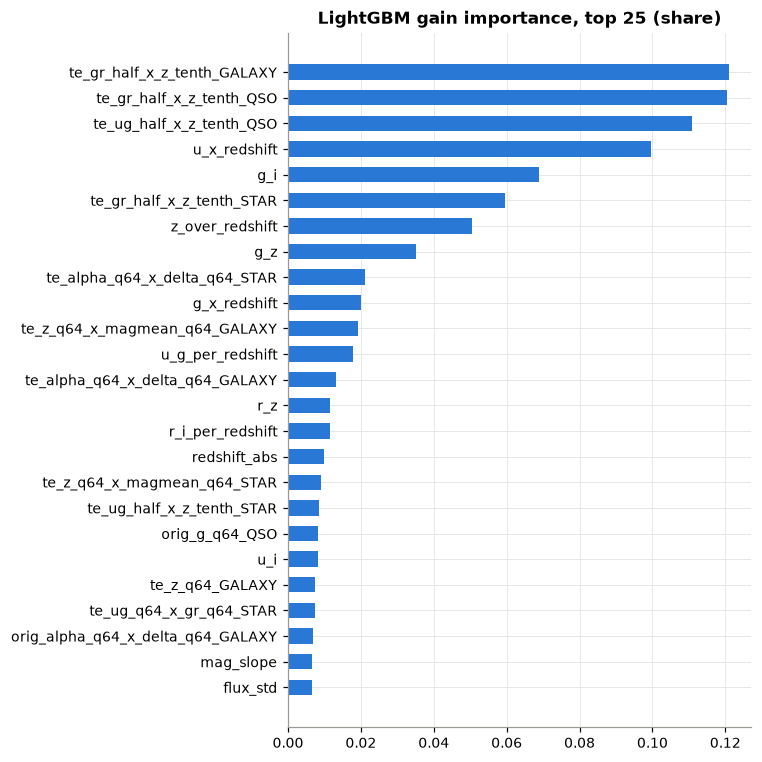

In [11]:
imp = pd.concat(importances, axis=1).mean(axis=1)
imp = (imp / imp.sum()).sort_values().tail(25)
fig, ax = plt.subplots(figsize=(7, 7))
ax.barh(imp.index, imp.values, color=BLUE, height=0.6)
ax.set_title('LightGBM gain importance, top 25 (share)')
plt.tight_layout(); plt.show()

## 6. Submission

In [12]:
sub = sample[['id']].copy()
assert (sub['id'].values == test['id'].values).all()
sub[TARGET] = CLASSES[(blend_test * mult).argmax(1)]
sub.to_csv('submission.csv', index=False)
print(sub.shape)
display(pd.DataFrame({'test predicted': sub[TARGET].value_counts(normalize=True),
                      'OOF predicted': pd.Series(CLASSES[pred_oof]).value_counts(normalize=True),
                      'train actual': train[TARGET].value_counts(normalize=True)}).round(4))

(247435, 2)


,test predicted,OOF predicted,train actual
GALAXY,0.6327,0.6316,0.6538
QSO,0.2070,0.2073,0.2029
STAR,0.1603,0.1611,0.1433


In [13]:
def kaggle_cli(*args):
    # The CLI prints a UTF-8 progress bar; Windows' default cp1252 decoding crashes on it
    return subprocess.run(['kaggle', 'competitions', *args], capture_output=True, text=True,
                          encoding='utf-8', errors='replace')

SUBMIT = True   # set to False to re-run the notebook without submitting again
msg = f'LGB + XGB (balanced weights) | blend w_lgb={w_lgb:.1f} + class multipliers | OOF BA {final_oof_ba:.5f}'
if SUBMIT:
    out = kaggle_cli('submit', COMP, '-f', 'submission.csv', '-m', msg)
    print(out.stdout[-2000:], out.stderr[-300:])

99 submissions remaining today.
Successfully submitted to Predicting Stellar Class    | 640k/3.32M [00:00<00:04, 659kB/s]
 21%|██        | 720k/3.32M [00:01<00:04, 548kB/s]
 25%|██▍       | 848k/3.32M [00:01<00:05, 508kB/s]
 39%|███▉      | 1.30M/3.32M [00:01<00:01, 1.15MB/s]
 98%|█████████▊| 3.25M/3.32M [00:01<00:00, 4.45MB/s]
100%|██████████| 3.32M/3.32M [00:02<00:00, 1.18MB/s]



In [14]:
# Wait for scoring. The competition is closed, so the late submission shows both public and private scores.
for _ in range(30):
    subs = pd.read_csv(io.StringIO(kaggle_cli('submissions', '-c', COMP, '-v').stdout))
    if 'pending' not in str(subs.loc[0, 'status']).lower():
        break
    time.sleep(20)
display(subs.head(3))

,ref,fileName,date,description,status,publicScore,privateScore
0,56968281,submission.csv,2026-10-08 19:08:04.410000,LGB + XGB (balanced weights) | blend w_lgb=0.7...,SubmissionStatus.COMPLETE,0.96774,0.96724
